# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   - Nama dataset: Wine Quality Dataset
   - sumber: UCI Machine Learning Repository 
   - Link: https://archive.ics.uci.edu/dataset/186/wine+quality
   
   


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
df = pd.read_csv('../winequality_raw/winequality-red.csv', sep=';')
print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
DUplicates:  240
Skewness & Kurtosis: 


,Skewness,Kurtosis
fixed acidity,0.982751,1.132143
volatile acidity,0.671593,1.225542
citric acid,0.318337,-0.788998
residual sugar,4.540655,28.617595
chlorides,5.680347,41.715787
free sulfur dioxide,1.250567,2.023562
total sulfur dioxide,1.515531,3.809824
density,0.071288,0.934079
pH,0.193683,0.806943
sulphates,2.428672,11.720251


EDA univariate - distribusi


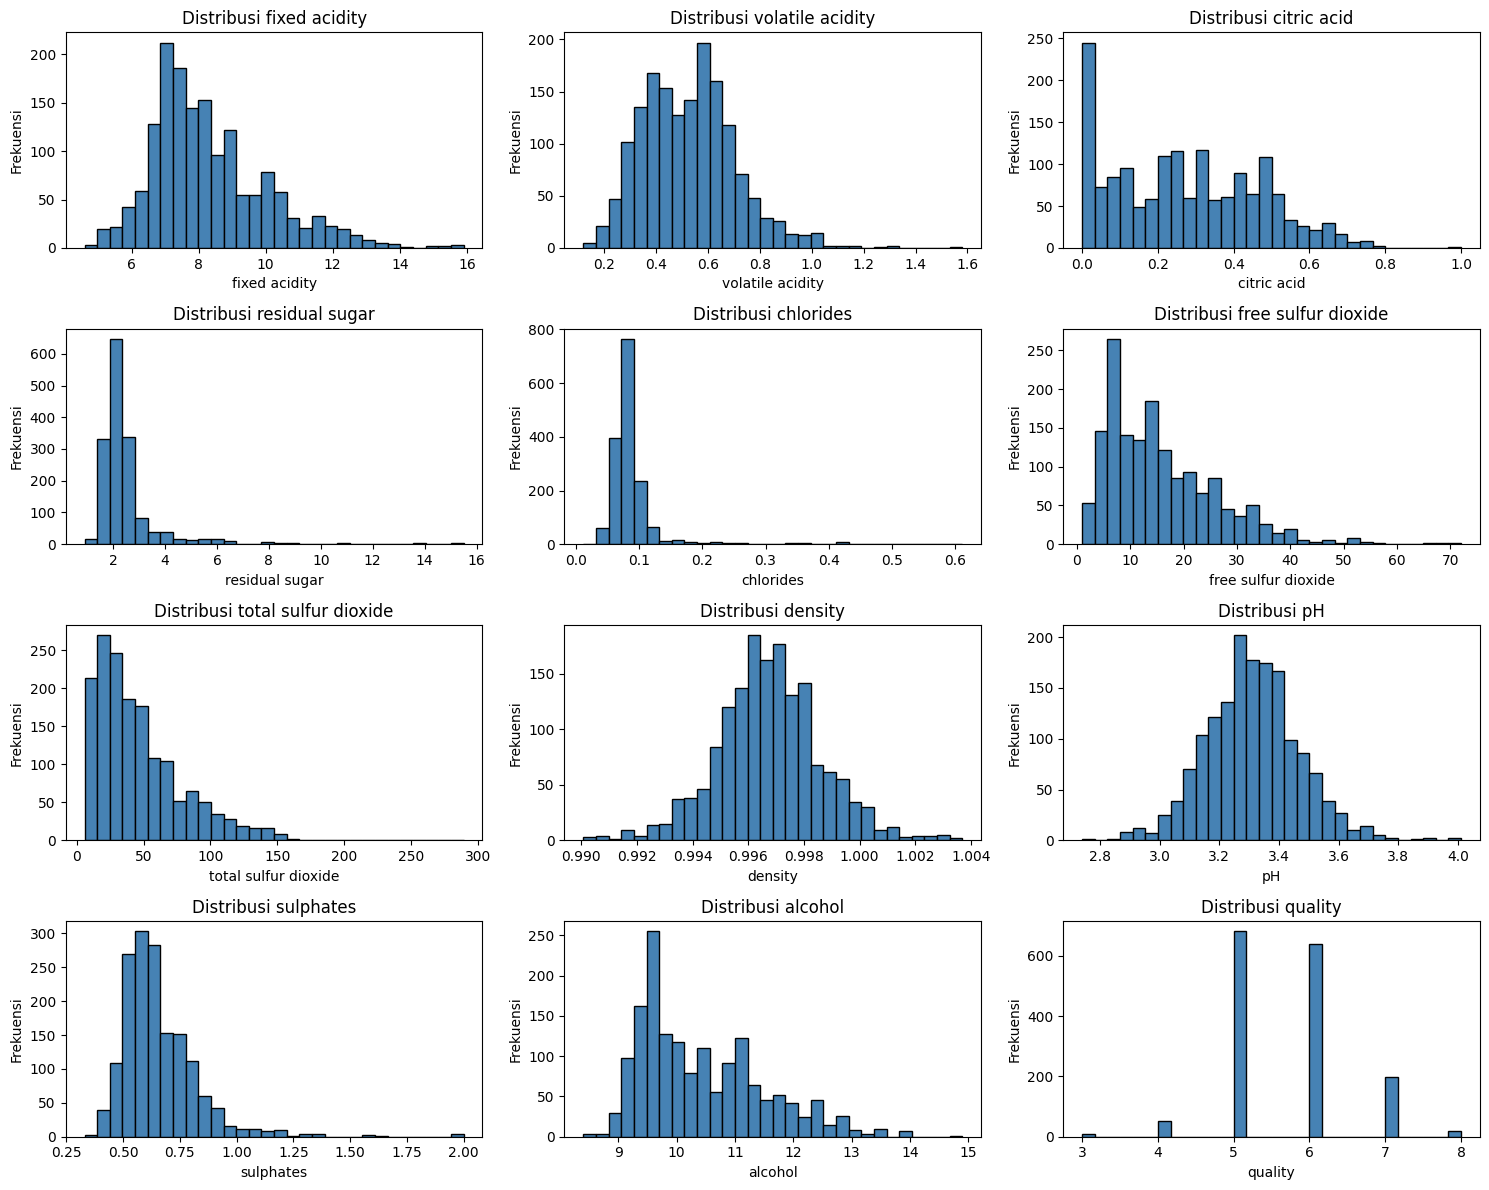

In [4]:
df.info()
df.describe()
df.isnull().sum()

print("DUplicates: ", df.duplicated().sum())
print("Skewness & Kurtosis: ")
skew_kurt = pd.DataFrame({
    'Skewness': df.skew(),
    'Kurtosis': df.kurt()
})
display(skew_kurt)

print("EDA univariate - distribusi")
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()


EDA univariate - boxplot


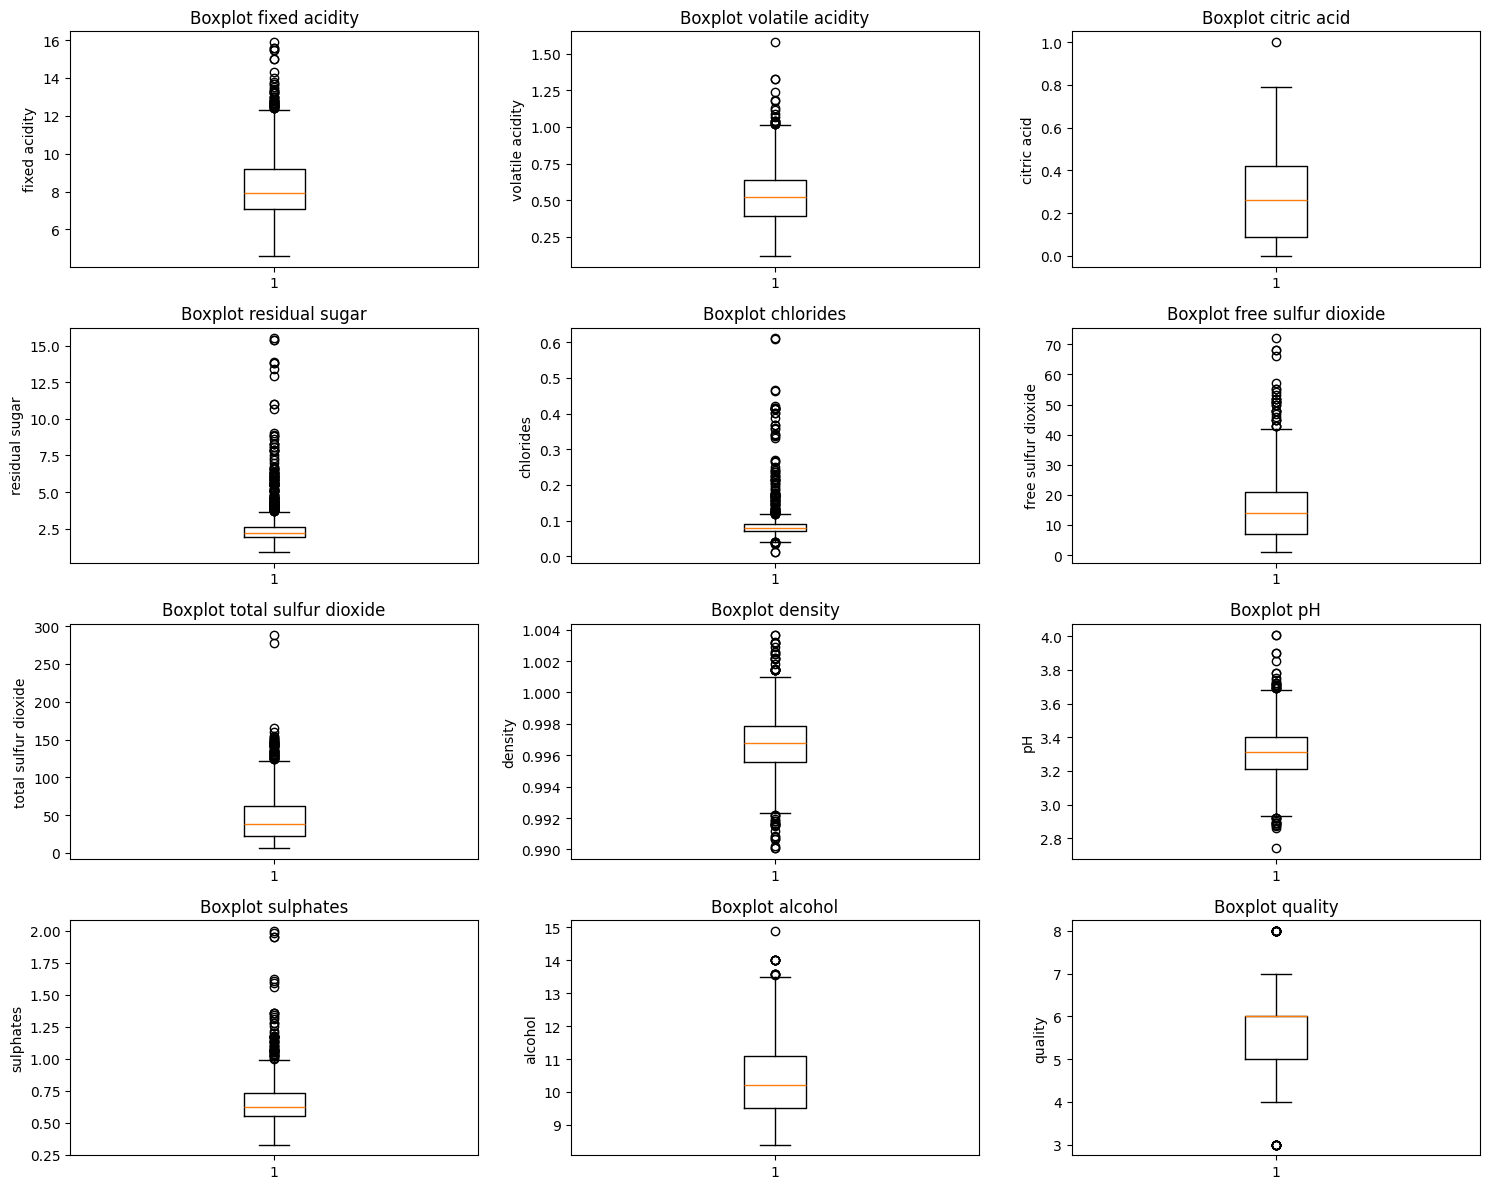

In [5]:
print("EDA univariate - boxplot")
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

Distribusi target variable (quality)


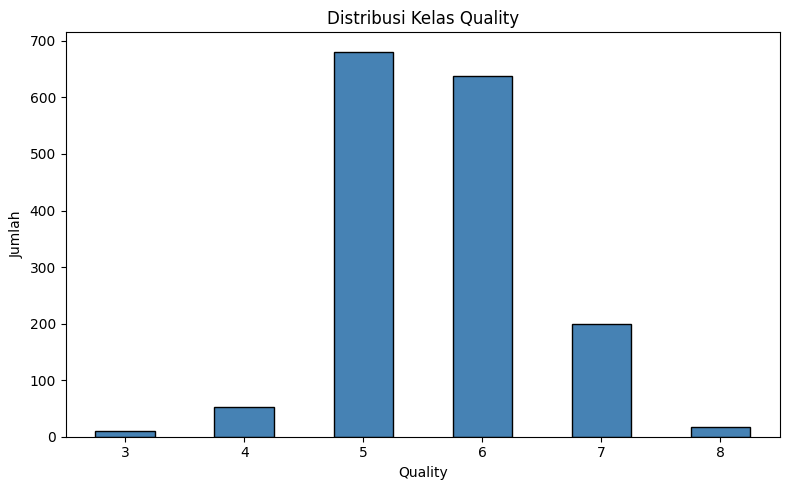

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [6]:
print("Distribusi target variable (quality)")
plt.figure(figsize=(8, 5))
df['quality'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Distribusi Kelas Quality')
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
display(df['quality'].value_counts())

EDA multivariate - korelasi


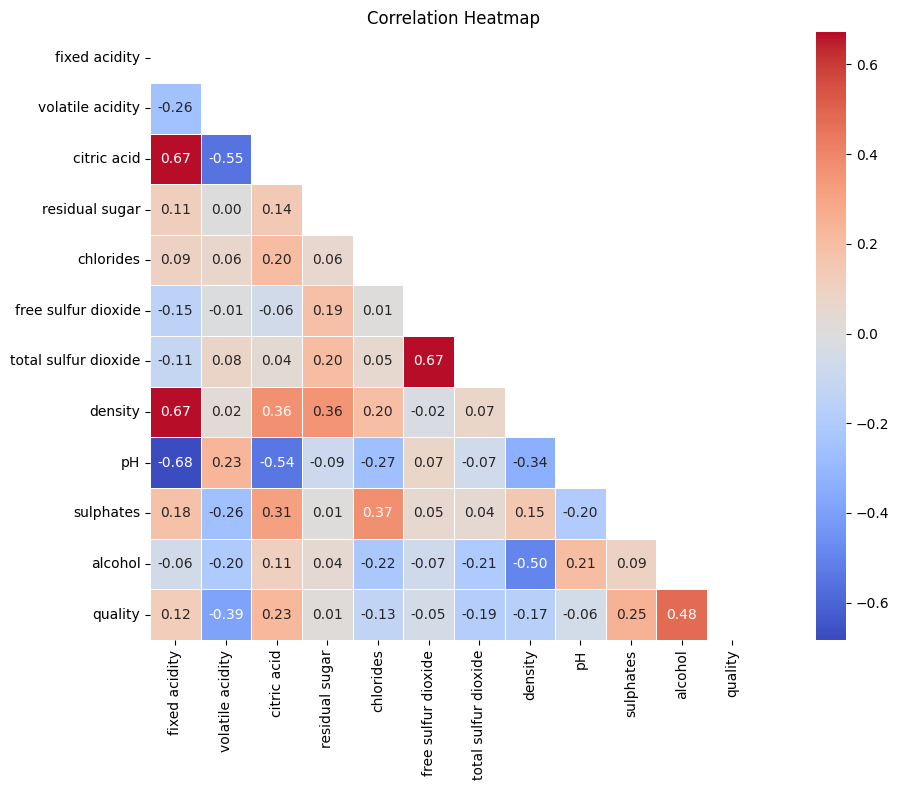

In [7]:
print("EDA multivariate - korelasi")
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

EDA multivariate - fitur vs target


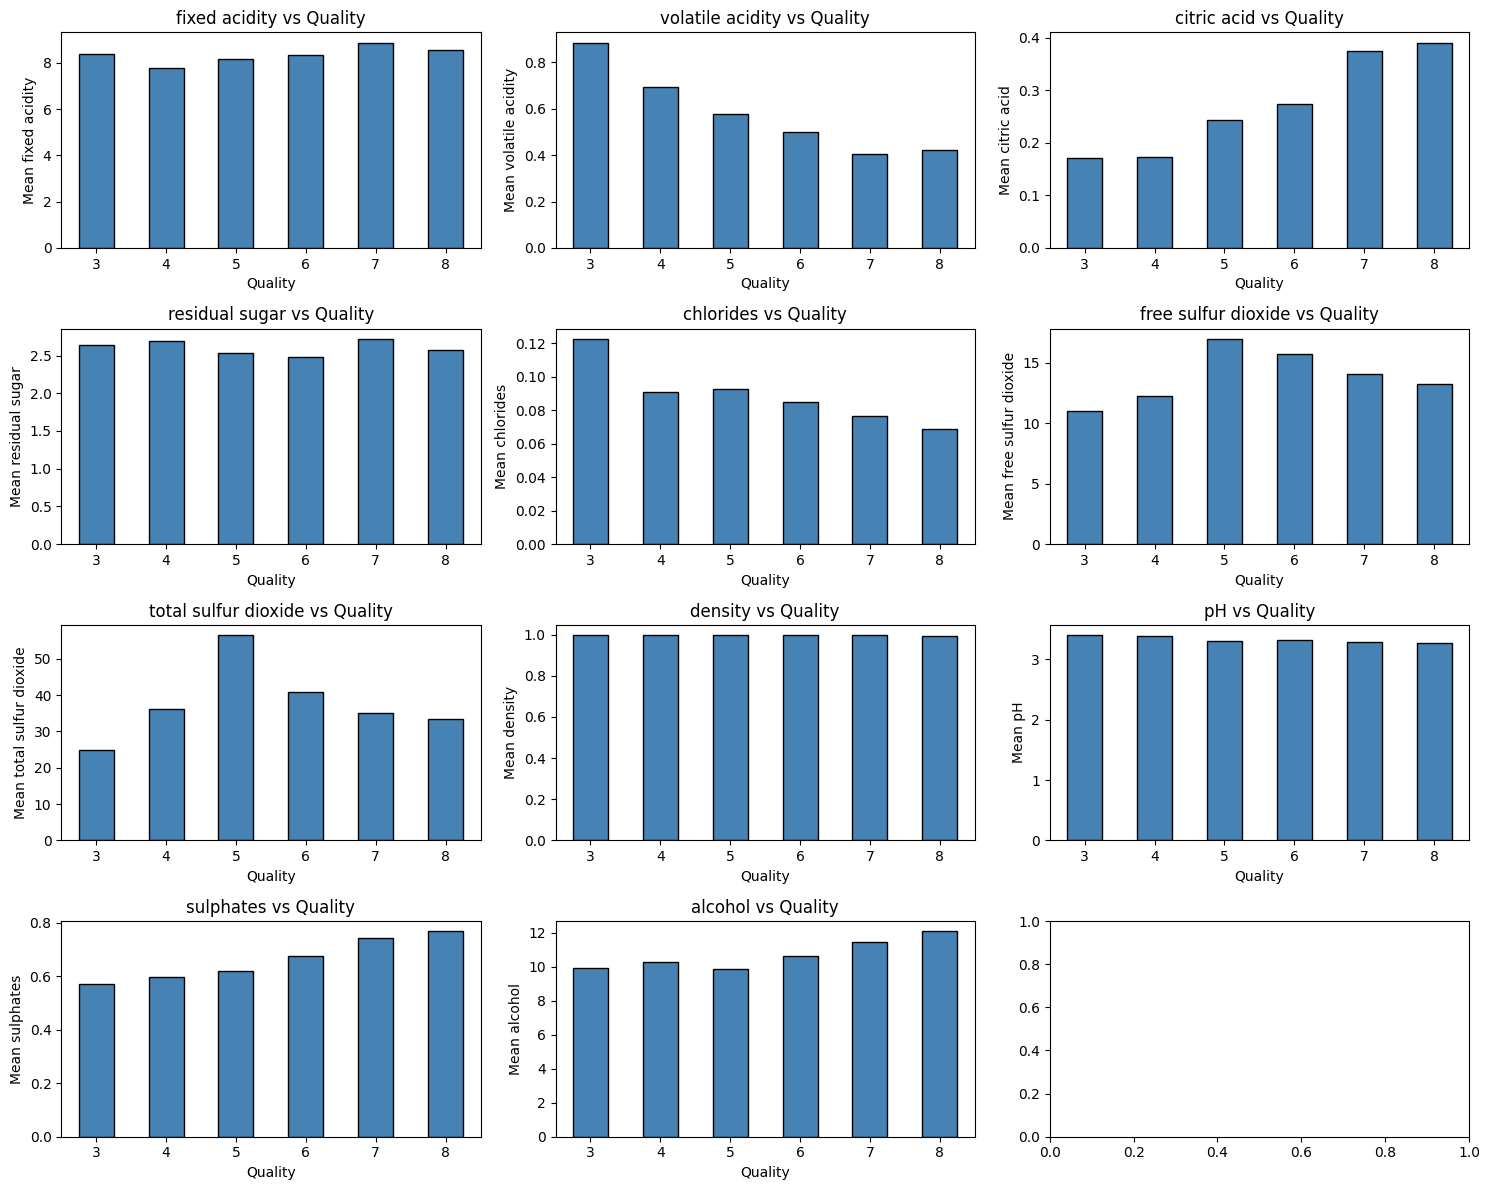

In [8]:
print("EDA multivariate - fitur vs target")
features = [col for col in df.columns if col != 'quality']
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    df.groupby('quality')[col].mean().plot(
        kind='bar', ax=axes[i], color='steelblue', edgecolor='black'
    )
    axes[i].set_title(f'{col} vs Quality')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(f'Mean {col}')
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

EDA multivariate - scatter top korelasi


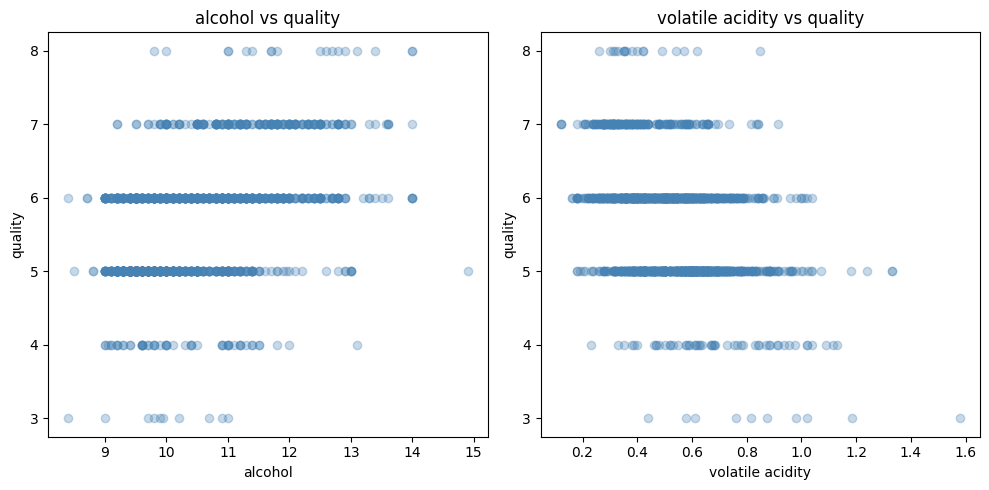

In [9]:
print("EDA multivariate - scatter top korelasi")
top2 = corr['quality'].abs().sort_values(ascending=False)[1:3].index.tolist()
plt.figure(figsize=(10, 5))
for i, col in enumerate(top2):
    plt.subplot(1, 2, i+1)
    plt.scatter(df[col], df['quality'], alpha=0.3, color='steelblue')
    plt.xlabel(col)
    plt.ylabel('quality')
    plt.title(f'{col} vs quality')
plt.tight_layout()
plt.show()

In [10]:
print("EDA numerikal - outlier detection")
outlier_summary = []
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outlier_summary.append({
        'Feature': col,
        'Jumlah Outlier': len(outliers),
        'Persentase (%)': round(len(outliers)/len(df)*100, 2)
    })
display(pd.DataFrame(outlier_summary))


EDA numerikal - outlier detection


,Feature,Jumlah Outlier,Persentase (%)
0,fixed acidity,49,3.06
1,volatile acidity,19,1.19
2,citric acid,1,0.06
3,residual sugar,155,9.69
4,chlorides,112,7.00
5,free sulfur dioxide,30,1.88
6,total sulfur dioxide,55,3.44
7,density,45,2.81
8,pH,35,2.19
9,sulphates,59,3.69


In [12]:
print("EDA insight summary")
print(f"• Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"• Missing values: {df.isnull().sum().sum()}")
print(f"• Duplikat: {df.duplicated().sum()}")
print(f"• Kelas terbanyak: quality = {df['quality'].value_counts().idxmax()}")
print(f"• Fitur paling berkorelasi dengan quality: {corr['quality'].abs().sort_values(ascending=False).index[1]}")
print(f"• Fitur skewness tertinggi: {df.skew().abs().idxmax()}")

EDA insight summary
• Dataset: 1359 baris, 12 kolom
• Missing values: 0
• Duplikat: 0
• Kelas terbanyak: quality = 5
• Fitur paling berkorelasi dengan quality: alcohol
• Fitur skewness tertinggi: chlorides


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
#  Handling Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)

# Remove Duplicates
df.drop_duplicates(inplace=True)

# Normalisasi Fitur
scaler = MinMaxScaler()
features = [col for col in df.columns if col != 'quality']
df[features] = scaler.fit_transform(df[features])

# Simpan Hasil
import os
os.makedirs('../preprocessing/winequality_preprocessing', exist_ok=True)
df.to_csv('../preprocessing/winequality_preprocessing/winequality_clean.csv', index=False)
print("Preprocessing selesai!")

Preprocessing selesai!
